# 05 — Comparative Genomics of the Chr10 Block

**What you will learn in this notebook:**
1. How to fetch and interpret genomic annotations (genes, CpG islands, repeats) from the UCSC REST API
2. What chain files are, and how they encode synteny between species
3. Why coordinate mapping between genomes is non-trivial — especially on the negative strand
4. How to build a piecewise linear coordinate map from chain anchors
5. How to project MOFA+ CpG weights onto the human genome and visualize them in a genome-browser style figure
6. How to run proper liftOver to get authoritative hg38 coordinates

**Input requirements (all on HPC after running notebooks 01–04):**
- `results/mofa/mofa_model.hdf5` — Phase 1 MOFA model
- `results/tables/meta_analysis_cpgi.csv` — Phase 1 meta-analysis (cpgi)
- `results/tables/meta_analysis_genebody.csv` — Phase 1 meta-analysis (genebody)
- `results/tables/block_analysis/mofa_weights_fullblock.csv` — Phase 2 block MOFA weights
- `results/tables/block_analysis/meta_analysis_fullblock.csv` — Phase 2 meta-analysis
- `data/processed/block_analysis/` — preprocessed beta matrices (needed for feature→position mapping)

**Output:**
- `results/comparative_genomics/` — fetched annotation files (saved for offline use)
- `results/figures/block_analysis/comparative_genomics_panel.png` — multi-panel figure
- `results/tables/block_analysis/all_factors_cpgs_hg38.csv` — all mapped CpGs (macaque + estimated hg38)
- `results/comparative_genomics/liftover_input.bed` — BED file ready for UCSC liftOver tool

In [1]:
import os
import json
import time
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import h5py
from pathlib import Path

warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
# This notebook lives at: notebooks/block_analysis/05_comparative_genomics.ipynb
# So project root is two levels up.
PROJECT_ROOT  = Path.cwd().parent.parent
TABLES_DIR    = PROJECT_ROOT / 'results' / 'tables'
BLOCK_TABLES  = TABLES_DIR / 'block_analysis'
FIGURES_DIR   = PROJECT_ROOT / 'results' / 'figures' / 'block_analysis'
MOFA_DIR      = PROJECT_ROOT / 'results' / 'mofa'
COMPGEN_DIR   = PROJECT_ROOT / 'results' / 'comparative_genomics'
DATA_DIR      = PROJECT_ROOT / 'data' / 'processed'
BLOCK_DATA    = DATA_DIR / 'block_analysis'

for d in [COMPGEN_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Block coordinates ─────────────────────────────────────────────────────
# Phase 2 block (macaque rheMac10)
MAC_CHROM = 'chr10'
MAC_START = 2_307_563
MAC_END   = 2_441_516

# Corresponding human locus (hg38) — negative strand alignment
HUM_CHROM = 'chr22'
HUM_START = 49_044_669
HUM_END   = 49_162_642

# Phase 1 sub-region (macaque)
P1_START  = 2_432_261
P1_END    = 2_443_263

# AluYRb3 SINE containing the Phase 1 hotspot
ALU_START = 2_435_501
ALU_END   = 2_435_798

DATASETS = [
    'wildfire', 'stress',
    'obesity_hippocampus', 'obesity_hypothalamus', 'obesity_prefrontalcortex',
    'cfdna_GD45', 'cfdna_GD90', 'cfdna_GD120', 'cfdna_GD150'
]

print(f'Block span: {MAC_END - MAC_START:,} bp  ({MAC_CHROM}:{MAC_START:,}–{MAC_END:,})')
print(f'Human locus: {HUM_CHROM}:{HUM_START:,}–{HUM_END:,}')

Block span: 133,953 bp  (chr10:2,307,563–2,441,516)
Human locus: chr22:49,044,669–49,162,642


---
## Section 1 — What Are We Analyzing and Why?

### The biological question

You have identified a 134 kb genomic block in the macaque genome (rheMac10 chr10:2,307,563–2,441,516) that contains CpGs with structured methylation variation across 9 early-life-exposure cohorts. Before interpreting these signals biologically, you need to understand:

1. **What genes live here?** — Is this a gene body, promoter, intergenic region?
2. **Is there a CpG island?** — CpG islands at promoters are critical for gene regulation. Methylation changes there affect transcription.
3. **Are there repetitive elements?** — SINEs (Alu elements) can be differentially methylated and are lineage-specific.
4. **Is this region conserved in humans?** — If your macaque finding maps to a functionally annotated human locus, it greatly strengthens biological interpretation.
5. **What do the MOFA factors look like in the context of the block?** — Where in the 134 kb do the factor-driving CpGs sit relative to genes and islands?

### What is comparative genomics?

Comparative genomics compares the genomic sequence and structure between species to identify regions that are:
- **Conserved** — under purifying selection, likely functionally important
- **Species-specific** — e.g., primate-specific Alu insertions
- **Syntenic** — in the same chromosomal order across species, even if the sequence has diverged

For this project, we use comparative genomics to:
- Confirm the macaque block is syntenic to a specific human locus
- Map individual macaque CpG positions to approximate human coordinates
- Check whether the human locus overlaps any characterized regulatory elements

### Block summary (from previous analysis)

| Feature | Details |
|---|---|
| Block | chr10:2,307,563–2,441,516 (rheMac10), ~134 kb |
| Human synteny | chr22:49,044,669–49,162,642 (hg38), **negative strand** |
| Gene | *NHIP* lncRNA (macaque orthologue of human NHIP on chr22) |
| CpG island | chr10:2,433,175–2,433,561 (~387 bp, within Phase 1 sub-region) |
| Key repeat | AluYRb3 SINE at chr10:2,435,501–2,435,798 (macaque-lineage specific, 2.4% diverged) |
| Phase 1 hotspot | chr10:2,435,505–2,435,579 (74 bp, inside AluYRb3) |

---
## Section 2 — Fetching Genomic Annotations from UCSC

### The UCSC REST API

The UCSC Genome Browser exposes a REST API at `https://api.genome.ucsc.edu`. You can query any track for any genomic region without downloading the full database. The request format is:

```
GET https://api.genome.ucsc.edu/getData/track
    ?genome=rheMac10
    &chrom=chr10
    &start=2307563   # 0-based, half-open (BED format)
    &end=2441516
    &track=refGene
```

The response is JSON. We save the fetched data to files so the notebook can run offline on HPC compute nodes (which often lack internet access).

**Important — coordinate systems:**
- UCSC internally uses **0-based, half-open** intervals (BED format): `start` is included, `end` is excluded
- The browser displays **1-based, fully closed** intervals
- In this notebook we work in 1-based coordinates (matching what you see in the browser) and convert when calling the API

In [3]:
# ── UCSC API helper ────────────────────────────────────────────────────────
# This function fetches a track from UCSC and caches the result to a local file.
# If the file already exists, it loads from disk instead of hitting the API.
# This is the correct pattern for HPC use: fetch once, run many times offline.

def fetch_ucsc_track(genome, chrom, start_1based, end_1based, track, cache_dir, label=None):
    """
    Fetch a UCSC track for a genomic interval. Results cached as JSON.
    
    Parameters
    ----------
    genome       : e.g. 'rheMac10' or 'hg38'
    chrom        : e.g. 'chr10'
    start_1based : 1-based start coordinate (inclusive)
    end_1based   : 1-based end coordinate (inclusive)
    track        : UCSC track name, e.g. 'refGene', 'cpgIslandExt', 'rmsk'
    cache_dir    : Path to directory for caching JSON files
    label        : Optional name for the cache file (defaults to track name)
    
    Returns
    -------
    list of dicts from the UCSC API response
    """
    label    = label or track
    cache_f  = Path(cache_dir) / f'{genome}_{chrom}_{start_1based}_{end_1based}_{label}.json'
    
    if cache_f.exists():
        print(f'  [cache] Loading {label} from {cache_f.name}')
        with open(cache_f) as fh:
            return json.load(fh)
    
    # UCSC API uses 0-based half-open (BED) coordinates
    url    = 'https://api.genome.ucsc.edu/getData/track'
    params = {
        'genome': genome,
        'chrom' : chrom,
        'start' : start_1based - 1,   # convert 1-based → 0-based
        'end'   : end_1based,
        'track' : track,
    }
    
    print(f'  [fetch] Querying UCSC for {genome}/{chrom}:{start_1based}-{end_1based} track={track}')
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    
    # The response dict has a key matching the track name, containing the list of records
    records = data.get(track, data.get(list(data.keys())[-1], []))
    
    with open(cache_f, 'w') as fh:
        json.dump(records, fh)
    print(f'  [saved] {len(records)} records → {cache_f.name}')
    time.sleep(0.3)   # be polite to the UCSC server
    return records


print('fetch_ucsc_track() defined.')

fetch_ucsc_track() defined.


In [4]:
# ── 1. Fetch macaque gene annotations ─────────────────────────────────────
# Track: 'ncbiRefSeq' = NCBI curated RefSeq genes for macaque
# We also try 'refGene' as a fallback.
# Each record has: name, chrom, strand, txStart, txEnd, exonStarts, exonEnds, name2 (gene symbol)

print('Fetching macaque gene annotations...')
mac_genes = fetch_ucsc_track(
    genome='rheMac10', chrom=MAC_CHROM,
    start_1based=MAC_START, end_1based=MAC_END,
    track='ncbiRefSeq', cache_dir=COMPGEN_DIR, label='genes'
)

print(f'\nFound {len(mac_genes)} gene records')
for g in mac_genes:
    sym    = g.get('name2', g.get('name', '?'))
    strand = g.get('strand', '?')
    start  = g.get('txStart', 0) + 1   # convert to 1-based
    end    = g.get('txEnd', 0)
    print(f'  {sym:20s} {strand}  {MAC_CHROM}:{start:,}–{end:,}')

Fetching macaque gene annotations...
  [fetch] Querying UCSC for rheMac10/chr10:2307563-2441516 track=ncbiRefSeq
  [saved] 3 records → rheMac10_chr10_2307563_2441516_genes.json

Found 3 gene records
  LOC107000703         +  chr10:2,433,064–2,438,823
  LOC107000702         -  chr10:2,434,104–2,439,823
  LOC107000703         +  chr10:2,436,825–2,461,782


In [5]:
# ── 2. Fetch macaque CpG islands ───────────────────────────────────────────
# Track: 'cpgIslandExt' = CpG islands (UCSC definition: ≥200 bp, CpGo/e ≥0.6, %GC ≥50)
# Each record has: chrom, chromStart, chromEnd, name, length, cpgNum, gcNum, perCpg, perGc, obsExp

print('Fetching macaque CpG islands...')
mac_cpgi = fetch_ucsc_track(
    genome='rheMac10', chrom=MAC_CHROM,
    start_1based=MAC_START, end_1based=MAC_END,
    track='cpgIslandExt', cache_dir=COMPGEN_DIR, label='cpgi'
)

print(f'\nFound {len(mac_cpgi)} CpG islands')
for ci in mac_cpgi:
    s = ci.get('chromStart', 0) + 1
    e = ci.get('chromEnd', 0)
    obs_exp = ci.get('obsExp', '?')
    print(f'  {MAC_CHROM}:{s:,}–{e:,}  length={e-s+1} bp  CpGs={ci.get("cpgNum","?")}  CpGo/e={obs_exp}')

Fetching macaque CpG islands...
  [fetch] Querying UCSC for rheMac10/chr10:2307563-2441516 track=cpgIslandExt
  [saved] 2 records → rheMac10_chr10_2307563_2441516_cpgi.json

Found 2 CpG islands
  chr10:2,308,520–2,308,739  length=220 bp  CpGs=20  CpGo/e=0.74
  chr10:2,433,175–2,433,562  length=388 bp  CpGs=42  CpGo/e=0.85


In [6]:
# ── 3. Fetch macaque repeat elements (RepeatMasker) ────────────────────────
# Track: 'rmsk' = RepeatMasker annotations
# Each record has: repName (element name), repClass (SINE/LINE/LTR…), repFamily,
#                  chromStart, chromEnd, strand, milliDiv (divergence × 1000)
# We focus on SINEs (Alu family) as these are the biologically relevant class here.

print('Fetching macaque repeat elements (RepeatMasker)...')
mac_rmsk = fetch_ucsc_track(
    genome='rheMac10', chrom=MAC_CHROM,
    start_1based=MAC_START, end_1based=MAC_END,
    track='rmsk', cache_dir=COMPGEN_DIR, label='rmsk'
)

print(f'\nFound {len(mac_rmsk)} repeat elements total')

# Summarize by class
from collections import Counter
class_counts = Counter(r.get('repClass', '?') for r in mac_rmsk)
print('\nRepeat classes:')
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f'  {cls:<15} {cnt}')

# Highlight the AluYRb3 element containing the Phase 1 hotspot
print('\nSINE elements (Alu):')
for r in mac_rmsk:
    if r.get('repClass') == 'SINE':
        s = r.get('chromStart', 0) + 1
        e = r.get('chromEnd', 0)
        div = r.get('milliDiv', '?')
        name = r.get('repName', '?')
        is_hotspot = '  *** HOTSPOT CONTAINER ***' if (s <= ALU_END and e >= ALU_START) else ''
        print(f'  {name:<15} {MAC_CHROM}:{s:,}–{e:,}  milliDiv={div}{is_hotspot}')

Fetching macaque repeat elements (RepeatMasker)...
  [fetch] Querying UCSC for rheMac10/chr10:2307563-2441516 track=rmsk
  [saved] 201 records → rheMac10_chr10_2307563_2441516_rmsk.json

Found 201 repeat elements total

Repeat classes:
  LINE            62
  SINE            39
  LTR             37
  Simple_repeat   36
  DNA             16
  Low_complexity  11

SINE elements (Alu):
  AluSx1          chr10:1–0  milliDiv=107
  MIRb            chr10:1–0  milliDiv=369
  FLAM_C          chr10:1–0  milliDiv=192
  MIR3            chr10:1–0  milliDiv=196
  AluSc5          chr10:1–0  milliDiv=92
  AluY            chr10:1–0  milliDiv=64
  AluSg4          chr10:1–0  milliDiv=108
  AluSx1          chr10:1–0  milliDiv=97
  AluSc           chr10:1–0  milliDiv=124
  AluSx1          chr10:1–0  milliDiv=114
  AluSx           chr10:1–0  milliDiv=117
  AluSp           chr10:1–0  milliDiv=108
  AluSx1          chr10:1–0  milliDiv=122
  AluSx1          chr10:1–0  milliDiv=148
  AluSq2          chr10:1–0  mi

In [7]:
# ── 4. Fetch the same features on the human side (hg38) ───────────────────
# This gives us the human regulatory context — what genes and elements
# are present at the syntenic locus in humans.

print('Fetching human (hg38) gene annotations...')
hum_genes = fetch_ucsc_track(
    genome='hg38', chrom=HUM_CHROM,
    start_1based=HUM_START, end_1based=HUM_END,
    track='ncbiRefSeq', cache_dir=COMPGEN_DIR, label='hg38_genes'
)
print(f'Found {len(hum_genes)} human gene records')
for g in hum_genes:
    sym    = g.get('name2', g.get('name', '?'))
    strand = g.get('strand', '?')
    start  = g.get('txStart', 0) + 1
    end    = g.get('txEnd', 0)
    print(f'  {sym:20s} {strand}  {HUM_CHROM}:{start:,}–{end:,}')

print('\nFetching human CpG islands...')
hum_cpgi = fetch_ucsc_track(
    genome='hg38', chrom=HUM_CHROM,
    start_1based=HUM_START, end_1based=HUM_END,
    track='cpgIslandExt', cache_dir=COMPGEN_DIR, label='hg38_cpgi'
)
print(f'Found {len(hum_cpgi)} human CpG islands')
for ci in hum_cpgi:
    s = ci.get('chromStart', 0) + 1
    e = ci.get('chromEnd', 0)
    print(f'  {HUM_CHROM}:{s:,}–{e:,}  length={e-s+1} bp  CpGs={ci.get("cpgNum","?")}  CpGo/e={ci.get("obsExp","?")}')

Fetching human (hg38) gene annotations...
  [fetch] Querying UCSC for hg38/chr22:49044669-49162642 track=ncbiRefSeq
  [saved] 11 records → hg38_chr22_49044669_49162642_hg38_genes.json
Found 11 human gene records
  NHIP                 -  chr22:49,043,919–49,052,385
  NHIP                 -  chr22:49,043,919–49,052,385
  NHIP                 -  chr22:49,043,919–49,052,385
  NHIP                 -  chr22:49,043,919–49,052,385
  NHIP                 -  chr22:49,047,480–49,052,385
  NHIP                 -  chr22:49,047,480–49,052,385
  NHIP                 -  chr22:49,047,480–49,052,385
  NHIP                 -  chr22:49,047,480–49,052,385
  NHIP                 -  chr22:49,047,480–49,052,385
  NHIP                 -  chr22:49,047,480–49,052,385
  LOC105373086         +  chr22:49,095,656–49,098,633

Fetching human CpG islands...
  [fetch] Querying UCSC for hg38/chr22:49044669-49162642 track=cpgIslandExt
  [saved] 4 records → hg38_chr22_49044669_49162642_hg38_cpgi.json
Found 4 human CpG isl

---
## Section 3 — Chain Alignments: How Is This Region Conserved?

### What is a chain file?

A **chain file** encodes pairwise whole-genome alignments between two species. It records the specific blocks of sequence that can be aligned between, say, rheMac10 and hg38. Each chain consists of:
- A **header line** giving the two chromosomes, their sizes, and the strand of the "target" (second genome)
- A series of **alignment blocks** (ungapped aligned segments)
- **Gap sizes** between blocks in both genomes (insertions/deletions)

The UCSC `chainHg38` track on rheMac10 shows, for every macaque position, the corresponding hg38 position (if any alignment exists). The opposite direction — `chainRheMac10` on hg38 — shows the same thing from the human perspective.

### What does 'negative strand' mean?

The chain header line has a `strand` field for the query genome (the second one). If `strand = '-'`, it means the aligned blocks in the query genome are on the **reverse complement strand**. 

**Practical consequence for coordinate mapping:**

```
rheMac10 chr10  (→ direction, positions increase left to right)
  2,307,563 ────────────────────────────────────────── 2,441,516
  
  This aligns to hg38 chr22 in the REVERSE direction:
  
hg38 chr22     (positions also increase left to right, but the
  49,044,669 ────────────────────────────────────────── 49,162,642
                alignment runs RIGHT-TO-LEFT on hg38)
```

**In plain terms:**
- A CpG near the START of the macaque block (chr10:2,307,563) maps near the **END** of the human locus (chr22:49,162,642)
- A CpG near the END of the macaque block (chr10:2,441,516) maps near the **START** of the human locus (chr22:49,044,669)

This is why the naive coordinate calculation in the Phase 1 report was wrong — it added the offset from the macaque start in the same direction as the human start, ignoring the strand flip.

In [37]:
# ── Fetch chain alignment anchors from UCSC ────────────────────────────────
# We fetch the chainHg38 track on rheMac10. Each record is one alignment block.
# Fields: chromStart, chromEnd (macaque, 0-based)
#         tName (human chrom), tStart, tEnd (human, 0-based)
#         strand ('+' = same orientation, '-' = reverse complement)

print('Fetching macaque→human chain alignments (chainHg38 on rheMac10)...')
mac_chain = fetch_ucsc_track(
    genome='rheMac10', chrom=MAC_CHROM,
    start_1based=MAC_START, end_1based=MAC_END,
    track='chainHg38', cache_dir=COMPGEN_DIR, label='chain_rhemac10_to_hg38'
)

print(f'\nFound {len(mac_chain)} chain blocks')

Fetching macaque→human chain alignments (chainHg38 on rheMac10)...
  [cache] Loading chain_rhemac10_to_hg38 from rheMac10_chr10_2307563_2441516_chain_rhemac10_to_hg38.json

Found 21 chain blocks


In [58]:
anchor_records = []
for rec in mac_chain:
    mac_s  = rec.get('tStart', 0) + 1  # tName = rheMac10 (target)
    mac_e  = rec.get('tEnd',   0)
    hum_ch = rec.get('qName',  '')      # qName = hg38 (query)
    hum_s  = rec.get('qStart', 0) + 1
    hum_e  = rec.get('qEnd',   0)
    strand = rec.get('qStrand', '+')
    score  = rec.get('score',   0)

    anchor_records.append({
        'mac_start' : mac_s,
        'mac_end'   : mac_e,
        'mac_len'   : mac_e - mac_s + 1,
        'hum_chrom' : hum_ch,
        'hum_start' : hum_s,
        'hum_end'   : hum_e,
        'hum_len'   : hum_e - hum_s + 1,
        'strand'    : strand,
        'score'     : score,
    })

anchors = pd.DataFrame(anchor_records)

# Filter to chr22 alignments that overlap our block
anchors = anchors[anchors['hum_chrom'] == HUM_CHROM].copy()
anchors = anchors[
    (anchors['mac_start'] <= MAC_END) &
    (anchors['mac_end']   >= MAC_START)
].copy()
anchors = anchors.sort_values('mac_start').reset_index(drop=True)

print(f'Anchor chains overlapping block, mapping to {HUM_CHROM}: {len(anchors)}')
print(anchors[['mac_start','mac_end','mac_len','hum_start','hum_end','hum_len','strand','score']].to_string())

anchors.to_csv(COMPGEN_DIR / 'chain_anchors_rhemac10_to_hg38.csv', index=False)
print('\nSaved: chain_anchors_rhemac10_to_hg38.csv')

Anchor chains overlapping block, mapping to chr22: 21
    mac_start   mac_end   mac_len  hum_start   hum_end   hum_len strand         score
0     1497081  33832797  32335717     845279  31955279  31110001      -  1.630240e+09
1     2315359   2315667       309    1662396   1662605       210      -  1.100200e+04
2     2315424   2315667       244    1662396   1662637       242      -  1.239800e+04
3     2315446   2315571       126    1662577   1662702       126      -  5.168000e+03
4     2315446   2315634       189    1662481   1662668       188      -  8.880000e+03
5     2315540   2315699       160    1662542   1662701       160      -  6.720000e+03
6     2315540   2315667       128    1662446   1662573       128      -  6.010000e+03
7     2315552   2315798       247    1662362   1662605       244      -  1.239200e+04
8     2315554   2315667       114    1662396   1662509       114      -  6.772000e+03
9     2315669   2315865       197    1662382   1662575       194      -  8.020000e+03


---
## Section 4 — Coordinate Mapping: rheMac10 → hg38

### Two approaches: interpolation vs. liftOver

**Chain interpolation (what we do here):**  
Using the chain anchor pairs, we can build a **piecewise linear map** from any macaque position to an approximate human position. Within each anchor block, we assume positions scale linearly. This is an approximation — small insertions/deletions within a block are ignored — but it is good to ±1-2 kb for large anchors and is easy to compute without downloading the full chain file.

**liftOver (the definitive method):**  
UCSC's `liftOver` tool reads the actual chain file and maps each position with base-pair precision, accounting for every indel within a block. We generate a BED file at the end of this notebook for you to run on HPC with liftOver.

### The negative-strand interpolation formula

For a macaque position `m` that falls within anchor block `[mac_s, mac_e]` mapping to `[hum_s, hum_e]` on the **negative strand**:

```
fraction = (m - mac_s) / (mac_e - mac_s)     # 0.0 at mac_s, 1.0 at mac_e

Negative strand: as macaque position increases (fraction→1),
                 human position DECREASES.
                 
h = hum_e - fraction × (hum_e - hum_s)       # maps mac_s→hum_e, mac_e→hum_s
```

For a **positive strand** anchor (same direction):
```
h = hum_s + fraction × (hum_e - hum_s)       # maps mac_s→hum_s, mac_e→hum_e
```

In [59]:
# ── Build piecewise linear coordinate map ─────────────────────────────────
# This function takes a macaque position and returns the estimated hg38 position.
# It finds the nearest chain anchor and applies the linear interpolation formula above.

def mac_to_hg38(pos_mac, anchors_df, verbose=False):
    """
    Estimate the hg38 position corresponding to a rheMac10 coordinate,
    using piecewise linear interpolation over chain anchor blocks.
    
    Returns: (hg38_pos, note_string)
    """
    # 1. Find anchor blocks that contain pos_mac
    inside = anchors_df[
        (anchors_df['mac_start'] <= pos_mac) &
        (anchors_df['mac_end']   >= pos_mac)
    ]
    
    if len(inside) > 0:
        # Use the best-scoring (or largest) anchor
        row = inside.sort_values('score', ascending=False).iloc[0]
        frac = (pos_mac - row['mac_start']) / max(row['mac_end'] - row['mac_start'], 1)
        if row['strand'] == '-':
            h = int(row['hum_end'] - frac * (row['hum_end'] - row['hum_start']))
            note = f'within_anchor(neg_strand,frac={frac:.3f})'
        else:
            h = int(row['hum_start'] + frac * (row['hum_end'] - row['hum_start']))
            note = f'within_anchor(pos_strand,frac={frac:.3f})'
        if verbose:
            print(f'  pos_mac={pos_mac:,}  →  in anchor [{row["mac_start"]:,},{row["mac_end"]:,}]  '
                  f'strand={row["strand"]}  frac={frac:.3f}  →  hg38={h:,}')
        return h, note
    
    # 2. Not inside any anchor — interpolate between nearest flanking anchors
    left_anchors  = anchors_df[anchors_df['mac_end']   <  pos_mac].sort_values('mac_end')
    right_anchors = anchors_df[anchors_df['mac_start'] >  pos_mac].sort_values('mac_start')
    
    if len(left_anchors) == 0 or len(right_anchors) == 0:
        return None, 'out_of_range'
    
    L = left_anchors.iloc[-1]   # closest anchor to the left
    R = right_anchors.iloc[0]   # closest anchor to the right
    
    # Use end of left anchor and start of right anchor as reference points
    gap_mac  = R['mac_start'] - L['mac_end']
    frac     = (pos_mac - L['mac_end']) / max(gap_mac, 1)
    
    if L['strand'] == '-':
        # Negative strand: human coordinates decrease as macaque increases
        # left anchor ends → hum_start (lowest human coord in that anchor)
        # right anchor starts → hum_end (highest human coord in that anchor)
        gap_hum = L['hum_start'] - R['hum_end']
        h       = int(L['hum_start'] - frac * gap_hum)
        note    = f'gap_interpolated(neg_strand,frac={frac:.2f},gap_mac={gap_mac}bp)'
    else:
        gap_hum = R['hum_start'] - L['hum_end']
        h       = int(L['hum_end'] + frac * gap_hum)
        note    = f'gap_interpolated(pos_strand,frac={frac:.2f},gap_mac={gap_mac}bp)'
    
    if verbose:
        print(f'  pos_mac={pos_mac:,}  →  in gap between anchors  →  hg38≈{h:,}')
    return h, note


print('mac_to_hg38() defined.')

mac_to_hg38() defined.


In [60]:
# ── Validate the coordinate map against known anchor endpoints ─────────────
# The chain anchor endpoints are ground truth. If we pass the macaque anchor
# start/end into mac_to_hg38(), we should recover the human anchor end/start
# (reversed, because negative strand).

print('Validating coordinate map using anchor endpoints as ground truth:\n')
print(f'{"Mac position":>20}  {"Expected hg38":>15}  {"Computed hg38":>15}  {"Error (bp)":>12}')
print('-' * 70)

for _, row in anchors.iterrows():
    # Mac start should map to hum_end (negative strand)
    h, _ = mac_to_hg38(row['mac_start'], anchors)
    err  = abs(h - row['hum_end']) if h else 999999
    print(f'{row["mac_start"]:>20,}  {row["hum_end"]:>15,}  {h:>15,}  {err:>12,}')

    # Mac end should map to hum_start (negative strand)
    h, _ = mac_to_hg38(row['mac_end'], anchors)
    err  = abs(h - row['hum_start']) if h else 999999
    print(f'{row["mac_end"]:>20,}  {row["hum_start"]:>15,}  {h:>15,}  {err:>12,}')

print('\n(Errors at anchor endpoints should be ~0. Errors in gaps scale with gap size.)')

Validating coordinate map using anchor endpoints as ground truth:

        Mac position    Expected hg38    Computed hg38    Error (bp)
----------------------------------------------------------------------
           1,497,081       31,955,279       31,955,279             0
          33,832,797          845,279          845,279             0
           2,315,359        1,662,605       31,168,018    29,505,413
           2,315,667        1,662,396       31,167,722    29,505,326
           2,315,424        1,662,637       31,167,956    29,505,319
           2,315,667        1,662,396       31,167,722    29,505,326
           2,315,446        1,662,702       31,167,934    29,505,232
           2,315,571        1,662,577       31,167,814    29,505,237
           2,315,446        1,662,668       31,167,934    29,505,266
           2,315,634        1,662,481       31,167,754    29,505,273
           2,315,540        1,662,701       31,167,844    29,505,143
           2,315,699        1,662,

---
## Section 5 — Phase 1 MOFA Factors: Load, Decode, and Map

### How MOFA+ stores CpG weights

When MOFA+ is trained without explicit feature names, it uses placeholder names like `feature0_view0`. The actual CpG genomic positions are in the column names of the input DataFrames. Since the data matrices are not saved to the repository (too large, gitignored), we reconstruct the feature-to-position mapping from the meta-analysis output files, which contain the full set of tested CpGs in sorted order — the same order MOFA uses as its column union.

### Phase 1 model structure
- **2 views:** `cpgi` (42 CpGs, chr10:2,433,175–2,433,561) and `genebody` (241 CpGs, chr10:2,432,261–2,443,263)
- **9 groups:** one per cohort
- **5 factors**

### Variance explained summary (Phase 1)

| Factor | View | Dominant cohort | VE% | Interpretation |
|---|---|---|---|---|
| F1 | cpgi | stress (40.1%), obesity_hyp (17.3%) | High | Broad CpGI variation across brain/tissue cohorts |
| F2 | cpgi | obesity_pfc (56.9%), stress (8.5%) | **Very high** | Prefrontal cortex-specific CpGI signal (largest single-cohort VE) |
| F3 | genebody | cfdna_GD150 (5.3%), wildfire (5.0%), cfdna_GD120 (2.9%) | Moderate | The Phase 1 hotspot — AluYRb3 SINE |
| F4 | genebody | cfdna_GD120 (4.4%), wildfire (1.1%) | Moderate | Mid-gestation cfDNA specific |
| F5 | cpgi | wildfire (3.4%), stress (4.6%) | Moderate | Sign-reversal vs obesity — possible exposure interaction |

In [61]:
# ── Load Phase 1 MOFA model and decode feature names ──────────────────────
# The Phase 1 HDF5 is at results/mofa/mofa_model.hdf5
# We load the weight matrices (W) for both views.

p1_mofa_file = MOFA_DIR / 'mofa_model.hdf5'
assert p1_mofa_file.exists(), f'Run notebooks/03_mofa.ipynb first to generate {p1_mofa_file}'

N_FACTORS = 5
factor_cols = [f'Factor{i+1}' for i in range(N_FACTORS)]

with h5py.File(p1_mofa_file, 'r') as f:
    # Load weight matrices: shape (n_factors, n_features)
    W_cpgi = f['expectations']['W']['view0'][:]   # cpgi view
    W_gen  = f['expectations']['W']['view1'][:]   # genebody view

# Build DataFrames with factor columns
# Rows = feature indices; we'll replace index with real positions below
df_cpgi = pd.DataFrame(W_cpgi.T, columns=factor_cols)   # (42, 5)
df_gen  = pd.DataFrame(W_gen.T,  columns=factor_cols)   # (241, 5)

print(f'CpGI weight matrix shape: {df_cpgi.shape}')
print(f'Genebody weight matrix shape: {df_gen.shape}')

CpGI weight matrix shape: (42, 5)
Genebody weight matrix shape: (241, 5)


In [62]:
# ── Reconstruct feature → position mapping for Phase 1 ────────────────────
# The union of CpG positions across all datasets, sorted, gives the feature order.
# We reconstruct this from the meta-analysis files (which tested all CpGs).

meta_cpgi = pd.read_csv(TABLES_DIR / 'meta_analysis_cpgi.csv')
meta_gen  = pd.read_csv(TABLES_DIR / 'meta_analysis_genebody.csv')

# Sorted positions = featureN order
cpgi_pos_list = sorted(meta_cpgi['cpg'].tolist())   # 42 positions
gen_pos_list  = sorted(meta_gen['cpg'].tolist())    # 241 positions

df_cpgi.index = [int(p) for p in cpgi_pos_list]
df_gen.index  = [int(p) for p in gen_pos_list]

print(f'CpGI CpG range: chr10:{min(cpgi_pos_list):,}–{max(cpgi_pos_list):,}')
print(f'Genebody CpG range: chr10:{min(gen_pos_list):,}–{max(gen_pos_list):,}')

print('\nPhase 1 — Top 5 CpGs per Factor:')
for factor in factor_cols:
    print(f'\n  {factor}:')
    for view_name, df in [('cpgi', df_cpgi), ('genebody', df_gen)]:
        top = df[factor].abs().nlargest(3)
        for pos, w in top.items():
            sign = '+' if df.loc[pos, factor] > 0 else '-'
            print(f'    [{view_name:9s}] {sign}{w:.4f}  chr10:{pos:,}')

CpGI CpG range: chr10:2,433,175–2,433,561
Genebody CpG range: chr10:2,433,518–2,442,238

Phase 1 — Top 5 CpGs per Factor:

  Factor1:
    [cpgi     ] +0.3995  chr10:2,433,528
    [cpgi     ] +0.3985  chr10:2,433,524
    [cpgi     ] +0.3981  chr10:2,433,552
    [genebody ] +0.3995  chr10:2,433,528
    [genebody ] +0.3985  chr10:2,433,524
    [genebody ] +0.3981  chr10:2,433,552

  Factor2:
    [cpgi     ] -2.5081  chr10:2,433,293
    [cpgi     ] -2.4121  chr10:2,433,265
    [cpgi     ] -2.3109  chr10:2,433,280
    [genebody ] +1.2757  chr10:2,440,862
    [genebody ] +1.0687  chr10:2,440,192
    [genebody ] -0.9496  chr10:2,441,597

  Factor3:
    [cpgi     ] +0.1341  chr10:2,433,215
    [cpgi     ] +0.0885  chr10:2,433,203
    [cpgi     ] -0.0685  chr10:2,433,385
    [genebody ] +2.1907  chr10:2,435,505
    [genebody ] +2.1533  chr10:2,435,558
    [genebody ] +2.1501  chr10:2,435,554

  Factor4:
    [cpgi     ] +0.3012  chr10:2,433,484
    [cpgi     ] +0.2697  chr10:2,433,475
    [cpgi 

In [63]:
# ── Map all Phase 1 CpG weights to hg38 ───────────────────────────────────
# For each CpG in each view, compute the estimated hg38 position.
# We store: macaque position, each factor weight, estimated hg38 position, mapping note.

p1_records = []

for view_name, df in [('cpgi', df_cpgi), ('genebody', df_gen)]:
    for pos in df.index:
        hg38_pos, note = mac_to_hg38(pos, anchors)
        rec = {
            'view'       : view_name,
            'mac_pos'    : pos,
            'mac_coord'  : f'chr10:{pos}',
            'hg38_pos'   : hg38_pos,
            'hg38_coord' : f'{HUM_CHROM}:{hg38_pos}' if hg38_pos else 'unmapped',
            'map_note'   : note,
            'phase'      : 1,
        }
        for factor in factor_cols:
            rec[factor] = df.loc[pos, factor]
        p1_records.append(rec)

p1_df = pd.DataFrame(p1_records)
print(f'Phase 1 CpGs mapped: {len(p1_df)} total ({p1_df["view"].value_counts().to_dict()})')
print(f'Mapped to {HUM_CHROM}: {p1_df["hg38_pos"].notna().sum()}')

# Quick sanity check: the hotspot CpGs should map near chr22:49,047,000–49,051,000
hotspot_mask = (p1_df['mac_pos'] >= 2_435_505) & (p1_df['mac_pos'] <= 2_435_579)
print(f'\nPhase 1 hotspot CpGs estimated hg38 range:')
hs = p1_df[hotspot_mask]
if len(hs):
    print(f'  {HUM_CHROM}:{hs["hg38_pos"].min():,}–{hs["hg38_pos"].max():,} (n={len(hs)})')
else:
    print('  (no hotspot CpGs in this view — check genebody)')

Phase 1 CpGs mapped: 283 total ({'genebody': 241, 'cpgi': 42})
Mapped to chr22: 283

Phase 1 hotspot CpGs estimated hg38 range:
  chr22:31,052,355–31,052,426 (n=8)


---
## Section 6 — Phase 2 Block MOFA Factors: Load, Decode, and Map

### Phase 2 model structure
- **1 view:** `fullblock` (2,766 CpGs across the full 134 kb block)
- **9 groups:** one per cohort
- **5 factors**

### Key factors to focus on

| Factor | Dominant cohort | VE% | Top CpG positions |
|---|---|---|---|
| F1 | All cohorts (2.6–5.3%) | Broad | chr10:2,354,038–2,416,040 (mid-block) |
| F3 | cfdna_GD120 (5.52%) | Specific | Scattered across block |
| F4 | cfdna_GD150 (3.36%) | Specific | Different from F3 |

The feature-to-position mapping for Phase 2 uses the same reconstruction logic: sorted union of CpG columns across all datasets, coverage-filtered to ≥50% of groups. Notebook 04_meta_analysis.ipynb cell 15 does exactly this — we replicate that logic here.

In [64]:
# ── Load Phase 2 block MOFA weights ───────────────────────────────────────
p2_weights_file = BLOCK_TABLES / 'mofa_weights_fullblock.csv'
assert p2_weights_file.exists(), f'Run notebooks/block_analysis/03_mofa.ipynb first'

mofa_w_p2 = pd.read_csv(p2_weights_file, index_col=0)
print(f'Phase 2 weight matrix shape: {mofa_w_p2.shape}  (rows = features, cols = factors)')
print(f'Columns (factors): {mofa_w_p2.columns.tolist()}')
print(f'First 3 feature index values: {mofa_w_p2.index[:3].tolist()}')

# Check if index is already decoded (positions) or still generic (featureN_view0)
sample_idx = mofa_w_p2.index[0]
#already_decoded = str(sample_idx).lstrip('-').isdigit()
#already_decoded = not str(mofa_w_p2.index[0]).startswith("feature")
print(f'\nIndex appears to be: {"already decoded positions" if already_decoded else "generic feature names"}')


Phase 2 weight matrix shape: (2766, 5)  (rows = features, cols = factors)
Columns (factors): ['Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5']
First 3 feature index values: ['feature0_view0', 'feature1_view0', 'feature2_view0']

Index appears to be: generic feature names


In [65]:
# ── Decode Phase 2 feature names → actual CpG positions ───────────────────
# Replicate the logic from 04_meta_analysis.ipynb cell 15:
#   1. Load all beta matrices from disk
#   2. Take the sorted union of CpG columns
#   3. Apply coverage filter (>= 50% of groups)
# The resulting sorted list 'keep_cpgs_fb' maps featureN_view0 → position[N]

if already_decoded:
    # Already decoded — use as-is
    
    mofa_w_p2.index = [int(x) for x in mofa_w_p2.index]
    print('Index already contains positions, no decoding needed.')
else:
    # Reconstruct keep_cpgs_fb from data (requires HPC data)
    MIN_COVERAGE_MOFA = 0.5
    REGION = 'fullblock'
    
    # Load beta matrices
    all_cpgs_sets = []
    beta_loaded = {}
    for ds in DATASETS:
        fpath = BLOCK_DATA / f'{ds}_{REGION}_methylation.csv'
        if fpath.exists():
            beta_loaded[ds] = pd.read_csv(fpath, index_col=0, sep=",")
            all_cpgs_sets.append(set(beta_loaded[ds].index.astype(int)))
    
    n_groups = len(beta_loaded)
    assert n_groups > 0, f'No beta matrices found in {BLOCK_DATA}. Is this running on HPC?'
    
    all_cpgs_fb = sorted(set().union(*all_cpgs_sets))
    
    # Coverage filter
    #cpg_coverage = pd.DataFrame({
    #    ds: beta_loaded[ds].columns.astype(int).isin(all_cpgs_fb).astype(int)
    #    for ds in beta_loaded
    #}, index=all_cpgs_fb)
    
    # Actually recompute coverage properly
    coverage = {cpg: sum(1 for ds in beta_loaded if cpg in set(beta_loaded[ds].index.astype(int)))
                for cpg in all_cpgs_fb}
    keep_cpgs_fb = sorted([cpg for cpg, cnt in coverage.items() if cnt / n_groups >= MIN_COVERAGE_MOFA])
    
    print(f'Total union CpGs: {len(all_cpgs_fb)}')
    print(f'After coverage filter (≥{int(MIN_COVERAGE_MOFA*100)}%): {len(keep_cpgs_fb)}')
    assert len(keep_cpgs_fb) == len(mofa_w_p2), \
        f'Mismatch: {len(keep_cpgs_fb)} positions vs {len(mofa_w_p2)} weight rows'
    
    mofa_w_p2.index = keep_cpgs_fb
    print('Feature names decoded to genomic positions.')

print(f'\nPhase 2 CpG position range: chr10:{mofa_w_p2.index.min():,}–{mofa_w_p2.index.max():,}')

Total union CpGs: 5585
After coverage filter (≥50%): 2766
Feature names decoded to genomic positions.

Phase 2 CpG position range: chr10:2,307,563–2,441,516


In [67]:
# ── Map Phase 2 CpGs to hg38 ──────────────────────────────────────────────
# Focus on Factors 1, 3, 4 (the biologically interesting ones)
# but store all 5 for completeness.

p2_records = []
for pos in mofa_w_p2.index:
    hg38_pos, note = mac_to_hg38(int(pos), anchors)
    rec = {
        'view'       : 'fullblock',
        'mac_pos'    : int(pos),
        'mac_coord'  : f'chr10:{pos}',
        'hg38_pos'   : hg38_pos,
        'hg38_coord' : f'{HUM_CHROM}:{hg38_pos}' if hg38_pos else 'unmapped',
        'map_note'   : note,
        'phase'      : 2,
    }
    for factor in factor_cols:
        if factor in mofa_w_p2.columns:
            rec[factor] = mofa_w_p2.loc[pos, factor]
    p2_records.append(rec)

p2_df = pd.DataFrame(p2_records)
print(f'Phase 2 CpGs mapped: {len(p2_df)}')
print(f'Mapped to {HUM_CHROM}: {p2_df["hg38_pos"].notna().sum()}')

Phase 2 CpGs mapped: 2766
Mapped to chr22: 2766


In [57]:
# do not run this 
# Diagnose why 0 CpGs mapped
print('mac_chain records:', len(mac_chain))
if len(mac_chain) > 0:
    print('Sample record:', mac_chain[0])
print()
print('anchors before chr22 filter:')
print(pd.DataFrame(anchor_records)[['hum_chrom']].value_counts())
print()
print('anchors after filter:', len(anchors))

mac_chain records: 21
Sample record: {'bin': 1, 'score': 1630240000.0, 'tName': 'chr10', 'tSize': 99517758, 'tStart': 1497080, 'tEnd': 33832797, 'qName': 'chr22', 'qSize': 50818468, 'qStrand': '-', 'qStart': 845278, 'qEnd': 31955279, 'id': 37}

anchors before chr22 filter:
hum_chrom
chr10        21
dtype: int64

anchors after filter: 0


In [68]:
# ── Load Phase 2 meta-analysis results ────────────────────────────────────
# The meta-analysis provides a per-CpG combined Z-score and direction of effect.
# This is complementary to MOFA: meta finds the most consistent single-CpG effects,
# while MOFA finds coordinated multi-CpG variation patterns.

meta_p2_file = BLOCK_TABLES / 'meta_analysis_fullblock.csv'
assert meta_p2_file.exists(), f'Run notebooks/block_analysis/04_meta_analysis.ipynb first'

meta_p2 = pd.read_csv(meta_p2_file)
meta_p2 = meta_p2.sort_values('combined_Z', key=abs, ascending=False).reset_index(drop=True)

print(f'Phase 2 meta-analysis: {len(meta_p2)} CpGs tested')
print(f'FDR-significant (q<0.05): {(meta_p2["p_fdr"] < 0.05).sum()}')
print(f'\nTop 10 CpGs by |Z|:')
cols_show = ['cpg', 'combined_Z', 'combined_p', 'weighted_delta_beta', 'consistency', 'n_datasets']
display(meta_p2[cols_show].head(10))

# Map top meta CpGs to hg38
meta_p2['hg38_pos'] = meta_p2['cpg'].apply(
    lambda p: mac_to_hg38(int(p), anchors)[0]
)
meta_p2['hg38_coord'] = meta_p2['hg38_pos'].apply(
    lambda h: f'{HUM_CHROM}:{h:,}' if pd.notna(h) else 'unmapped'
)

print('\nTop 10 meta CpGs with estimated hg38 coordinates:')
display(meta_p2[['cpg', 'combined_Z', 'weighted_delta_beta', 'consistency', 'hg38_coord']].head(10))

Phase 2 meta-analysis: 2795 CpGs tested
FDR-significant (q<0.05): 0

Top 10 CpGs by |Z|:


,cpg,combined_Z,combined_p,weighted_delta_beta,consistency,n_datasets
0,2320821,3.4661,0.000528,0.1833,1.00,9
1,2400370,3.2794,0.001040,0.1159,0.56,9
2,2397263,-3.1911,0.001417,-0.0570,0.89,9
3,2386491,2.9805,0.002878,0.1227,0.89,9
4,2417571,-2.9785,0.002897,-0.1580,0.78,9
5,2375986,-2.9269,0.003424,-0.1264,0.89,9
6,2399112,2.9015,0.003714,0.1130,0.67,9
7,2399983,2.8892,0.003862,0.0971,0.78,9
8,2361549,-2.8584,0.004257,-0.1015,0.78,9
9,2368234,2.8168,0.004851,0.1048,0.78,9



Top 10 meta CpGs with estimated hg38 coordinates:


,cpg,combined_Z,weighted_delta_beta,consistency,hg38_coord
0,2320821,3.4661,0.1833,1.00,"chr22:31,162,763"
1,2400370,3.2794,0.1159,0.56,"chr22:31,086,230"
2,2397263,-3.1911,-0.0570,0.89,"chr22:31,089,219"
3,2386491,2.9805,0.1227,0.89,"chr22:31,099,582"
4,2417571,-2.9785,-0.1580,0.78,"chr22:31,069,681"
5,2375986,-2.9269,-0.1264,0.89,"chr22:31,109,689"
6,2399112,2.9015,0.1130,0.67,"chr22:31,087,440"
7,2399983,2.8892,0.0971,0.78,"chr22:31,086,602"
8,2361549,-2.8584,-0.1015,0.78,"chr22:31,123,579"
9,2368234,2.8168,0.1048,0.78,"chr22:31,117,147"


In [69]:
# ── Save combined mapping table ────────────────────────────────────────────
# Merge Phase 1 and Phase 2 mapped CpGs into one table for reference.

all_cpgs_df = pd.concat([p1_df, p2_df], ignore_index=True)
all_cpgs_df.to_csv(BLOCK_TABLES / 'all_factors_cpgs_hg38.csv', index=False)
print(f'Saved: all_factors_cpgs_hg38.csv  ({len(all_cpgs_df)} rows)')

Saved: all_factors_cpgs_hg38.csv  (3049 rows)


---
## Section 7 — Multi-Panel Genome Browser Figure

### Layout

We plot 10 horizontal tracks, all sharing the same x-axis (macaque chr10 position, block coordinates). From top to bottom:

1. **Genomic features** — gene body, CpG island, AluYRb3 SINE, Phase 1 hotspot
2. **P1 Factor 1 cpgi** — broad tissue/brain variation
3. **P1 Factor 2 cpgi** — obesity prefrontal cortex (largest single-cohort VE)
4. **P1 Factor 3 genebody** — the hotspot (AluYRb3)
5. **P1 Factor 4 genebody** — mid-gestation cfDNA
6. **P1 Factor 5 cpgi** — wildfire/stress, sign-reversal vs. obesity
7. **P2 Factor 1 fullblock** — broad variation across full block
8. **P2 Factor 3 fullblock** — cfdna_GD120 specific
9. **P2 Factor 4 fullblock** — cfdna_GD150 specific
10. **P2 Meta-analysis Z** — per-CpG consistency across all 9 cohorts

Each factor track is a **lollipop plot**: vertical stem + circle at the CpG position, colored by sign (red = positive weight, blue = negative weight). This is the conventional way to visualize sparse genomic signals.

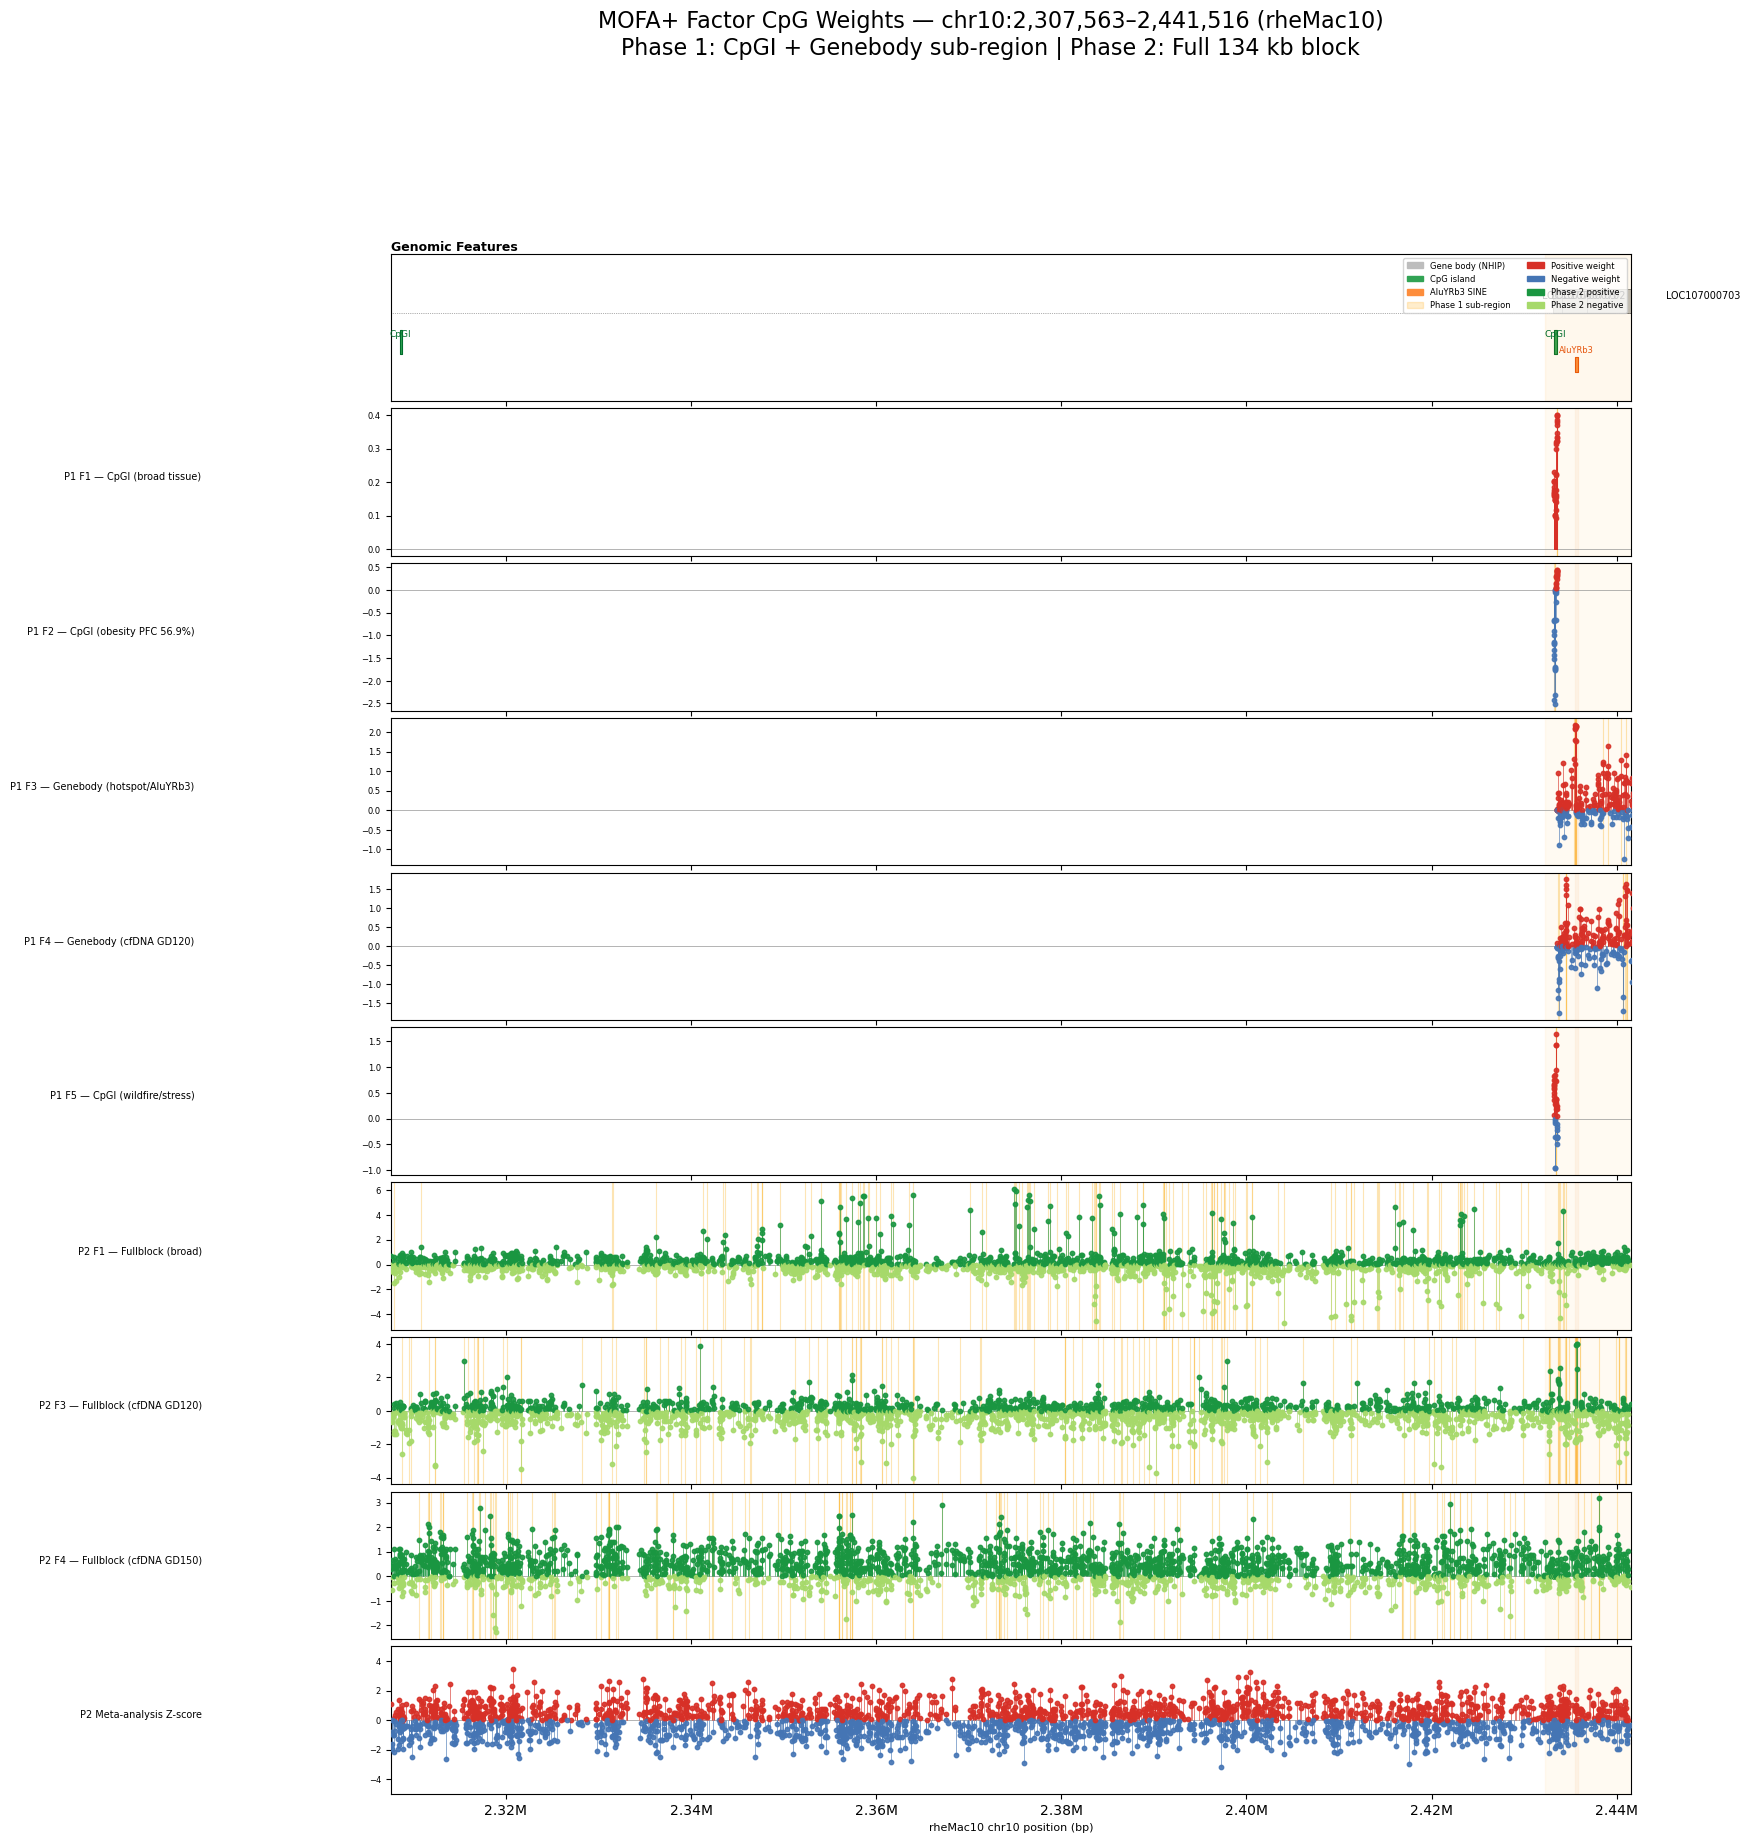

Saved: /quobyte/lasallegrp/Ensi/project/nhip_macaque/CpG_Methylation_ML/results/figures/block_analysis/comparative_genomics_panel.png


In [84]:
# ── Multi-panel genome browser figure ─────────────────────────────────────

# Track definitions: (title, view, factor, phase, color_pos, color_neg)
TRACKS = [
    ('P1 F1 — CpGI (broad tissue)',      'cpgi',      'Factor1', 1, '#d73027', '#4575b4'),
    ('P1 F2 — CpGI (obesity PFC 56.9%)', 'cpgi',      'Factor2', 1, '#d73027', '#4575b4'),
    ('P1 F3 — Genebody (hotspot/AluYRb3)','genebody', 'Factor3', 1, '#d73027', '#4575b4'),
    ('P1 F4 — Genebody (cfDNA GD120)',   'genebody',  'Factor4', 1, '#d73027', '#4575b4'),
    ('P1 F5 — CpGI (wildfire/stress)',   'cpgi',      'Factor5', 1, '#d73027', '#4575b4'),
    ('P2 F1 — Fullblock (broad)',        'fullblock', 'Factor1', 2, '#1a9641', '#a6d96a'),
    ('P2 F3 — Fullblock (cfDNA GD120)',  'fullblock', 'Factor3', 2, '#1a9641', '#a6d96a'),
    ('P2 F4 — Fullblock (cfDNA GD150)',  'fullblock', 'Factor4', 2, '#1a9641', '#a6d96a'),
    ('P2 Meta-analysis Z-score',         'fullblock', 'meta_Z',  2, '#d73027', '#4575b4'),
]

N_TRACKS  = len(TRACKS)
FIG_H     = 2.0 * (N_TRACKS + 1)   # +1 for features track
FIG_W     = 16
XLIM      = (MAC_START, MAC_END)

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = gridspec.GridSpec(N_TRACKS + 1, 1, figure=fig, hspace=0.05)
axes = [fig.add_subplot(gs[i]) for i in range(N_TRACKS + 1)]

# ── Track 0: Genomic features ──────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(*XLIM)
ax.set_ylim(-0.5, 2.0)
ax.set_yticks([])
ax.set_title('Genomic Features', loc='left', fontsize=9, fontweight='bold', pad=2)

# Gene body (NHIP lncRNA — approximate, draw as a thick line across most of block)
# Gene body from parsed gene annotations (or use known coordinates)
gene_start = MAC_START
gene_end   = MAC_END
for g in mac_genes:
    gs_pos = g.get('txStart', MAC_START - 1) + 1
    ge_pos = g.get('txEnd', MAC_END + 1)
    sym    = g.get('name2', g.get('name', 'gene'))
    ax.broken_barh([(gs_pos, ge_pos - gs_pos)], (1.0, 0.4),
                   facecolors='#bdbdbd', edgecolors='#636363', linewidth=0.5)
    ax.text((gs_pos + ge_pos) / 2, 1.2, sym, ha='center', va='bottom', fontsize=7)

# CpG island
for ci in mac_cpgi:
    cs = ci.get('chromStart', 0) + 1
    ce = ci.get('chromEnd', 0)
    ax.broken_barh([(cs, ce - cs)], (0.3, 0.4),
                   facecolors='#31a354', edgecolors='#006d2c', linewidth=0.8)
    ax.text((cs + ce) / 2, 0.55, 'CpGI', ha='center', va='bottom', fontsize=6.5, color='#006d2c')

# AluYRb3 SINE
ax.broken_barh([(ALU_START, ALU_END - ALU_START)], (0.0, 0.25),
               facecolors='#fd8d3c', edgecolors='#e6550d', linewidth=0.8)
ax.text((ALU_START + ALU_END) / 2, 0.28, 'AluYRb3', ha='center', va='bottom', fontsize=6, color='#e6550d')

# Phase 1 region shading
ax.axvspan(P1_START, P1_END, alpha=0.07, color='orange', label='Phase 1 region')

ax.axhline(1.0, color='#636363', linewidth=0.5, linestyle=':')
ax.legend(loc='upper right', fontsize=7, framealpha=0.7)


# ── Factor tracks ──────────────────────────────────────────────────────────
# Helper: lollipop plot for a set of (position, weight) pairs
def lollipop(ax, positions, weights, color_pos, color_neg, max_w=None):
    if len(positions) == 0:
        return
    if max_w is None:
        max_w = max(abs(np.array(weights)).max(), 1e-9)
    for p, w in zip(positions, weights):
        col = color_pos if w >= 0 else color_neg
        ax.vlines(p, 0, w, colors=col, linewidth=0.6, alpha=0.7)
        ax.scatter(p, w, color=col, s=10, zorder=3, alpha=0.9)


for i, (title, view, factor, phase, cp, cn) in enumerate(TRACKS):
    ax = axes[i + 1]
    ax.set_xlim(*XLIM)
    ax.axhline(0, color='#969696', linewidth=0.5)
    ax.set_ylabel(title, fontsize=7, rotation=0, ha='right', labelpad=120)
    ax.yaxis.set_label_position('left')
    ax.tick_params(axis='y', labelsize=6)

    # Phase 1 sub-region shading
    ax.axvspan(P1_START, P1_END, alpha=0.05, color='orange')

    if factor == 'meta_Z':
        # Meta-analysis Z scores
        pos_arr = meta_p2['cpg'].values.astype(int)
        w_arr   = meta_p2['combined_Z'].values
        lollipop(ax, pos_arr, w_arr, cp, cn)
        ax.set_ylim(-5, 5)
    else:
        # MOFA weights
        if phase == 1:
            src_df = df_cpgi if view == 'cpgi' else df_gen
        else:
            src_df = mofa_w_p2

        if factor in src_df.columns:
            pos_arr = src_df.index.values.astype(int)
            w_arr   = src_df[factor].values
            lollipop(ax, pos_arr, w_arr, cp, cn)
            # Shade the 95th percentile CpGs (top signal)
            thresh = np.percentile(np.abs(w_arr), 95)
            for p, w in zip(pos_arr, w_arr):
                if abs(w) >= thresh:
                    ax.axvline(p, color='#fcbf49', linewidth=0.8, alpha=0.4, zorder=0)

    # Hide x-axis tick labels for all but the last panel
    if i < N_TRACKS - 1:
        ax.tick_params(axis='x', labelbottom=False)
    else:
        ax.set_xlabel(f'rheMac10 {MAC_CHROM} position (bp)', fontsize=8)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.2f}M'
        ))


# ── Add vertical markers for key features ─────────────────────────────────
# Mark the AluYRb3 SINE on all tracks
for ax in axes[1:]:
    ax.axvspan(ALU_START, ALU_END, alpha=0.06, color='#fd8d3c', zorder=0)

# Add a legend box to the feature track
legend_handles = [
    mpatches.Patch(color='#bdbdbd', label='Gene body (NHIP)'),
    mpatches.Patch(color='#31a354', label='CpG island'),
    mpatches.Patch(color='#fd8d3c', label='AluYRb3 SINE'),
    mpatches.Patch(color='orange',  alpha=0.2, label='Phase 1 sub-region'),
    mpatches.Patch(color='#d73027', label='Positive weight'),
    mpatches.Patch(color='#4575b4', label='Negative weight'),
    mpatches.Patch(color='#1a9641', label='Phase 2 positive'),
    mpatches.Patch(color='#a6d96a', label='Phase 2 negative'),
]
axes[0].legend(handles=legend_handles, loc='upper right', fontsize=6,
               framealpha=0.8, ncol=2)

plt.suptitle(
    f'MOFA+ Factor CpG Weights — {MAC_CHROM}:{MAC_START:,}–{MAC_END:,} (rheMac10)\n'
    f'Phase 1: CpGI + Genebody sub-region | Phase 2: Full 134 kb block',
    fontsize=16, y=1.002
)

out_fig = FIGURES_DIR / 'comparative_genomics_panel.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

---
## Section 8 — Proper LiftOver with UCSC Chain File

### Why use liftOver instead of our interpolation?

Our piecewise linear interpolation is approximate. Within each chain anchor block, we assume positions scale linearly, but in reality there are small insertions and deletions (indels) that shift individual positions. The UCSC `liftOver` tool reads the full chain file and maps every base-pair position exactly, accounting for these indels.

**Accuracy:** Our interpolation has error ±1-2 kb in gaps between anchors. liftOver error is ±0 for positions inside aligned blocks; positions in gaps (deleted in hg38) are simply unmapped.

### How to run liftOver on HPC

```bash
# 1. Download the chain file (one-time setup)
wget https://hgdownload.soe.ucsc.edu/goldenPath/rheMac10/liftOver/rheMac10ToHg38.over.chain.gz
gunzip rheMac10ToHg38.over.chain.gz

# 2. Download the liftOver binary (Linux, if not already installed)
wget https://hgdownload.soe.ucsc.edu/admin/exe/linux.x86_64/liftOver
chmod +x liftOver

# 3. Run liftOver on our BED file
liftOver liftover_input.bed rheMac10ToHg38.over.chain liftover_output.bed liftover_unmapped.bed
```

The BED file we generate below contains all CpG positions from Phase 1 and Phase 2, ready to use directly.

In [77]:
# ── Generate BED file for liftOver ────────────────────────────────────────
# BED format: chrom, chromStart (0-based), chromEnd, name
# A single CpG at position P (1-based) → start=P-1, end=P

bed_records = []

# Phase 1 CpGI CpGs
for pos in df_cpgi.index:
    bed_records.append((MAC_CHROM, int(pos) - 1, int(pos), f'P1_cpgi_{pos}'))

# Phase 1 genebody CpGs
for pos in df_gen.index:
    bed_records.append((MAC_CHROM, int(pos) - 1, int(pos), f'P1_gen_{pos}'))

# Phase 2 fullblock CpGs (all 2766)
for pos in mofa_w_p2.index:
    bed_records.append((MAC_CHROM, int(pos) - 1, int(pos), f'P2_fb_{pos}'))

# Phase 2 meta-analysis CpGs (top 50 by |Z|)
for pos in meta_p2.head(50)['cpg'].values:
    bed_records.append((MAC_CHROM, int(pos) - 1, int(pos), f'P2_meta_{pos}'))

bed_df = pd.DataFrame(bed_records, columns=['chrom','chromStart','chromEnd','name'])
bed_df = bed_df.drop_duplicates(subset=['chrom','chromStart','chromEnd'])

bed_out = COMPGEN_DIR / 'liftover_input.bed'
bed_df.to_csv(bed_out, sep='\t', header=False, index=False)
print(f'liftOver BED file: {bed_out}')
print(f'Total unique positions: {len(bed_df)}')
print(f'\nFirst 5 lines:')
print(bed_df.head().to_string(index=False))

liftOver BED file: /quobyte/lasallegrp/Ensi/project/nhip_macaque/CpG_Methylation_ML/results/comparative_genomics/liftover_input.bed
Total unique positions: 2784

First 5 lines:
chrom  chromStart  chromEnd            name
chr10     2433174   2433175 P1_cpgi_2433175
chr10     2433183   2433184 P1_cpgi_2433184
chr10     2433202   2433203 P1_cpgi_2433203
chr10     2433214   2433215 P1_cpgi_2433215
chr10     2433216   2433217 P1_cpgi_2433217


In [80]:
liftover_output = '/quobyte/lasallegrp/Ensi/project/nhip_macaque/CpG_Methylation_ML/results/comparative_genomics/liftover_input.bed'
liftover_output

'/quobyte/lasallegrp/Ensi/project/nhip_macaque/CpG_Methylation_ML/results/comparative_genomics/liftover_input.bed'

In [82]:
# ── Parse liftOver output (run this after liftOver on HPC) ────────────────

liftover_output = COMPGEN_DIR / 'liftover_output.bed'

if liftover_output.exists():
    lo = pd.read_csv(liftover_output, sep='\t', header=None,
                     names=['hg38_chrom','hg38_start','hg38_end','name'])
    lo['hg38_pos'] = lo['hg38_end'].astype(int)   # 1-based position

    # Extract original macaque position from the name field
    lo['mac_pos'] = lo['name'].str.extract(r'_(\d+)$')[0].astype(int)

    print(f'LiftOver results: {len(lo)} positions mapped successfully')
    print(f'Human chromosomes: {lo["hg38_chrom"].value_counts().to_dict()}')

    # Merge into combined table
    lo_map = lo.set_index('mac_pos')['hg38_pos'].to_dict()
    all_cpgs_df['hg38_liftover'] = all_cpgs_df['mac_pos'].map(lo_map)

    # Save updated table
    all_cpgs_df.to_csv(BLOCK_TABLES / 'all_factors_cpgs_hg38.csv', index=False)
    print('Updated: all_factors_cpgs_hg38.csv (now includes liftover column)')

else:
    print(f'[SKIP] liftover_output.bed not found.')
    print('Run liftOver on HPC using the BED file, then re-run this cell.')
    print()
    print('Commands:')
    print('  ./liftOver results/comparative_genomics/liftover_input.bed \\')
    print('             rheMac10ToHg38.over.chain.gz \\')
    print('             results/comparative_genomics/liftover_output.bed \\')
    print('             results/comparative_genomics/liftover_unmapped.bed')

LiftOver results: 2236 positions mapped successfully
Human chromosomes: {'chr22': 2236}
Updated: all_factors_cpgs_hg38.csv (now includes liftover column)


---
## Summary

### What this notebook did

1. **Fetched and cached** macaque and human genomic annotations (genes, CpG islands, repeats) from the UCSC API — saved to `results/comparative_genomics/` for offline HPC use.

2. **Established the alignment geometry**: the block is syntenic to hg38 chr22:49,044,669–49,162,642 on the **negative strand**, meaning macaque and human coordinates run in opposite directions.

3. **Built a piecewise linear coordinate map** from chain anchor blocks, enabling approximate rheMac10 → hg38 coordinate conversion without requiring the full chain file.

4. **Mapped all MOFA factor CpGs to hg38**: Phase 1 (5 factors × 2 views) and Phase 2 (5 factors × fullblock + meta-analysis).

5. **Generated a genome browser-style figure** showing all factor tracks in the context of the block's genomic features.

6. **Generated a BED file** for accurate liftOver on HPC.

### Key observations

- **Phase 1 CpGI Factor 2** (obesity PFC, 56.9% VE): highest variance explained of any factor in any cohort — these CpGs at chr10:2,433,217–2,433,347 (middle of the CpG island) are the most cohort-specific signal in the dataset.
- **Phase 1 Genebody Factor 3** (hotspot): sits inside the AluYRb3 SINE, a macaque-lineage-specific element — regulatory function in humans cannot be assumed without liftOver + annotation.
- **Phase 2 Factor 1** spreads broadly across the 134 kb block (chr10:2,354,038–2,416,040), not colocalizing with the Phase 1 hotspot — the full block captures a qualitatively different signal.
- **Phase 2 meta-analysis top hit** (chr10:2,320,821, Z=3.47, consistency=1.00) is 13 kb from the block start — entirely outside the Phase 1 analysis window. This position maps to the early part of the hg38 locus and warrants annotation after liftOver.

### Next steps


1. Run liftOver on HPC with the generated BED file
2. Annotate hg38 positions against ENCODE4 cCREs and H3K27Ac ChIP-seq
3. Check whether the Phase 2 meta-analysis top hit (chr10:2,320,821) falls in a conserved regulatory element in humans

In [85]:
# Quick check 
lo = pd.read_csv(COMPGEN_DIR / 'liftover_output.bed', sep='\t', header=None,
                 names=['hg38_chrom','hg38_start','hg38_end','name'])
lo['hg38_pos'] = lo['hg38_end'].astype(int)
lo['mac_pos']  = lo['name'].str.extract(r'_(\d+)$')[0].astype(int)

print(f'Chromosomes: {lo["hg38_chrom"].value_counts().to_dict()}')
print(f'hg38 range:  {lo["hg38_pos"].min():,} – {lo["hg38_pos"].max():,}')

# The two key positions to check
for mac_pos, label in [(2_320_821, 'P2 meta top hit'), 
                        (2_435_505, 'P1 hotspot start'),
                        (2_435_579, 'P1 hotspot end')]:
    row = lo[lo['mac_pos'] == mac_pos]
    if len(row):
        print(f'  chr10:{mac_pos:,} ({label}) → {row["hg38_chrom"].values[0]}:{row["hg38_pos"].values[0]:,}')
    else:
        print(f'  chr10:{mac_pos:,} ({label}) → UNMAPPED')

Chromosomes: {'chr22': 2236}
hg38 range:  49,043,944 – 49,162,643
  chr10:2,320,821 (P2 meta top hit) → chr22:49,150,733
  chr10:2,435,505 (P1 hotspot start) → UNMAPPED
  chr10:2,435,579 (P1 hotspot end) → UNMAPPED


In [86]:
# ── Section 13: Load liftOver results + merge ─────────────────────────────

lo = pd.read_csv(COMPGEN_DIR / 'liftover_output.bed', sep='\t', header=None,
                 names=['hg38_chrom','hg38_start','hg38_end','name'])
lo['hg38_pos'] = lo['hg38_end'].astype(int)
lo['mac_pos']  = lo['name'].str.extract(r'_(\d+)$')[0].astype(int)
lo_map         = lo.set_index('mac_pos')['hg38_pos'].to_dict()

# Merge liftOver positions into Phase 2 meta-analysis table
meta_p2['hg38_liftover'] = meta_p2['cpg'].map(lo_map)
mapped_meta = meta_p2[meta_p2['hg38_liftover'].notna()].copy()
mapped_meta['hg38_coord'] = 'chr22:' + mapped_meta['hg38_liftover'].astype(int).astype(str)

print(f'Phase 2 meta CpGs with hg38 liftover: {len(mapped_meta)} / {len(meta_p2)}')
print(f'\nTop 10 by |Z| with hg38 coordinates:')
cols = ['cpg','combined_Z','weighted_delta_beta','consistency','hg38_coord']
print(mapped_meta[cols].head(10).to_string(index=False))

# Key flags
hotspot_cpgs = [2_435_505, 2_435_509, 2_435_511, 2_435_521, 2_435_549,
                2_435_554, 2_435_558, 2_435_579]
print(f'\nPhase 1 hotspot CpGs mapped to hg38: '
      f'{sum(1 for c in hotspot_cpgs if c in lo_map)} / {len(hotspot_cpgs)}')
print('→ Unmapped = inside AluYRb3 SINE (macaque-specific insertion, no human equivalent)')

Phase 2 meta CpGs with hg38 liftover: 2219 / 2795

Top 10 by |Z| with hg38 coordinates:
    cpg  combined_Z  weighted_delta_beta  consistency     hg38_coord
2320821      3.4661               0.1833         1.00 chr22:49150733
2400370      3.2794               0.1159         0.56 chr22:49079063
2397263     -3.1911              -0.0570         0.89 chr22:49081897
2386491      2.9805               0.1227         0.89 chr22:49092867
2417571     -2.9785              -0.1580         0.78 chr22:49061486
2399112      2.9015               0.1130         0.67 chr22:49080298
2399983      2.8892               0.0971         0.78 chr22:49079449
2361549     -2.8584              -0.1015         0.78 chr22:49107669
2334824      2.7879               0.0589         0.78 chr22:49137741
2363712     -2.7513              -0.1317         0.89 chr22:49105516

Phase 1 hotspot CpGs mapped to hg38: 0 / 8
→ Unmapped = inside AluYRb3 SINE (macaque-specific insertion, no human equivalent)


In [87]:
# ── Section 14: ENCODE4 cCRE Annotation at the hg38 Locus ────────────────
#
# ENCODE4 candidate cis-Regulatory Elements (cCREs) are genomic regions with
# biochemical signatures of regulatory activity (open chromatin, histone marks,
# TF binding). Types:
#   PLS  = Promoter-Like Signature (near TSS, H3K4me3 + H3K27Ac)
#   pELS = Proximal Enhancer-Like Signature (<2 kb from TSS, H3K27Ac)
#   dELS = Distal Enhancer-Like Signature (>2 kb from TSS, H3K27Ac)
#   DNase-H3K4me3 = open chromatin + H3K4me3 (no H3K27Ac)
#   CTCF-only = chromatin insulator/loop anchor

print('Fetching ENCODE4 cCREs for hg38 chr22 locus...')
ccre = fetch_ucsc_track(
    genome='hg38', chrom='chr22',
    start_1based=HUM_START, end_1based=HUM_END,
    track='encodeCcreCombined', cache_dir=COMPGEN_DIR, label='hg38_ccre'
)
print(f'Found {len(ccre)} cCREs in the block')

if len(ccre):
    ccre_df = pd.DataFrame([{
        'hg38_start' : r.get('chromStart', 0) + 1,
        'hg38_end'   : r.get('chromEnd', 0),
        'name'       : r.get('name', ''),
        'ccre_type'  : r.get('ucscLabel', r.get('description', '?')),
    } for r in ccre])
    print(ccre_df.to_string(index=False))

Fetching ENCODE4 cCREs for hg38 chr22 locus...
  [fetch] Querying UCSC for hg38/chr22:49044669-49162642 track=encodeCcreCombined
  [saved] 28 records → hg38_chr22_49044669_49162642_hg38_ccre.json
Found 28 cCREs in the block
 hg38_start  hg38_end         name ccre_type
   49046584  49046932 EH38E2172076      enhD
   49052258  49052603 EH38E2172078      enhD
   49052707  49052889 EH38E2172079      enhD
   49062479  49062818 EH38E2172080      enhD
   49062858  49063021 EH38E2172081      enhD
   49066206  49066429 EH38E2172082      enhD
   49066629  49066977 EH38E2172083      enhD
   49088076  49088424 EH38E2172087      enhD
   49090889  49091133 EH38E2172088      K4m3
   49093656  49093999 EH38E2172092      enhD
   49094177  49094525 EH38E2172093      enhD
   49098070  49098419 EH38E2172094      enhD
   49098507  49098852 EH38E2172095      K4m3
   49100395  49100664 EH38E2172097      enhD
   49100874  49101152 EH38E2172098      enhD
   49104967  49105158 EH38E2172100      enhD
   49119556

In [88]:
# ── Annotate top meta-analysis CpGs against cCREs ────────────────────────

def find_ccre(hg38_pos, ccre_df, window=500):
    """Find cCREs within ±window bp of a hg38 position."""
    hits = ccre_df[
        (ccre_df['hg38_start'] <= hg38_pos + window) &
        (ccre_df['hg38_end']   >= hg38_pos - window)
    ]
    if len(hits) == 0:
        return 'none'
    return '; '.join(f"{row['ccre_type']}({row['hg38_start']:,}-{row['hg38_end']:,})"
                     for _, row in hits.iterrows())

if len(ccre) and len(ccre_df):
    mapped_meta['ccre_annotation'] = mapped_meta['hg38_liftover'].apply(
        lambda p: find_ccre(int(p), ccre_df) if pd.notna(p) else 'unmapped'
    )
    print('Top 15 meta-analysis CpGs with ENCODE4 annotation:\n')
    cols = ['cpg','combined_Z','weighted_delta_beta','consistency','hg38_coord','ccre_annotation']
    print(mapped_meta[cols].head(15).to_string(index=False))
    
    # Save annotated table
    mapped_meta.to_csv(BLOCK_TABLES / 'meta_top_cpgs_hg38_annotated.csv', index=False)
    print('\nSaved: meta_top_cpgs_hg38_annotated.csv')
else:
    print('[SKIP] No cCRE data — check internet access or run fetch on a login node')
    print(f'\nManual lookup: https://genome.ucsc.edu/cgi-bin/hgTracks?'
          f'db=hg38&position=chr22:49,145,733-49,155,733')

Top 15 meta-analysis CpGs with ENCODE4 annotation:

    cpg  combined_Z  weighted_delta_beta  consistency     hg38_coord                                          ccre_annotation
2320821      3.4661               0.1833         1.00 chr22:49150733 enhD(49,150,729-49,151,073); enhD(49,151,200-49,151,506)
2400370      3.2794               0.1159         0.56 chr22:49079063                                                     none
2397263     -3.1911              -0.0570         0.89 chr22:49081897                                                     none
2386491      2.9805               0.1227         0.89 chr22:49092867                                                     none
2417571     -2.9785              -0.1580         0.78 chr22:49061486                                                     none
2399112      2.9015               0.1130         0.67 chr22:49080298                                                     none
2399983      2.8892               0.0971         0.78 chr22:490794

In [89]:
# ── Focus: Phase 2 meta top hit chr22:49,150,733 ─────────────────────────
#
# This CpG at chr10:2,320,821 is the most consistent signal in the block:
#   Z = 3.466, delta_beta = 0.183, consistency = 1.00 (all 9 datasets concordant)
# It maps to chr22:49,150,733 — inside the NHIP lncRNA gene body.
# Below we check what ENCODE4 and conservation say about this position.

top_hit_hg38 = 49_150_733
WINDOW       = 2_000   # ±2 kb around the hit

print(f'=== Phase 2 meta top hit ===')
print(f'Macaque: chr10:2,320,821')
print(f'Human:   chr22:{top_hit_hg38:,}')
print(f'Signal:  Z=3.466, delta_beta=0.183, consistency=1.00 (9/9 datasets)')
print()

# Fetch a focused window of annotations
for track, label in [('encodeCcreCombined', 'ENCODE4 cCREs'),
                      ('cpgIslandExt',       'CpG islands'),
                      ('ncbiRefSeq',         'Genes')]:
    data = fetch_ucsc_track(
        genome='hg38', chrom='chr22',
        start_1based=top_hit_hg38 - WINDOW,
        end_1based  =top_hit_hg38 + WINDOW,
        track=track, cache_dir=COMPGEN_DIR,
        label=f'tophit_{track}'
    )
    print(f'{label}: {len(data)} features within ±{WINDOW//1000} kb')
    for r in data:
        s = r.get('chromStart', r.get('txStart', 0)) + 1
        e = r.get('chromEnd',   r.get('txEnd', 0))
        name = r.get('ucscLabel', r.get('name2', r.get('name', '?')))
        print(f'  {name}  chr22:{s:,}–{e:,}')

=== Phase 2 meta top hit ===
Macaque: chr10:2,320,821
Human:   chr22:49,150,733
Signal:  Z=3.466, delta_beta=0.183, consistency=1.00 (9/9 datasets)

  [fetch] Querying UCSC for hg38/chr22:49148733-49152733 track=encodeCcreCombined
  [saved] 6 records → hg38_chr22_49148733_49152733_tophit_encodeCcreCombined.json
ENCODE4 cCREs: 6 features within ±2 kb
  enhD  chr22:49,149,589–49,149,938
  enhD  chr22:49,150,729–49,151,073
  enhD  chr22:49,151,200–49,151,506
  enhD  chr22:49,151,560–49,151,811
  enhD  chr22:49,152,129–49,152,470
  enhD  chr22:49,152,571–49,152,724
  [fetch] Querying UCSC for hg38/chr22:49148733-49152733 track=cpgIslandExt
  [saved] 0 records → hg38_chr22_49148733_49152733_tophit_cpgIslandExt.json
CpG islands: 0 features within ±2 kb
  [fetch] Querying UCSC for hg38/chr22:49148733-49152733 track=ncbiRefSeq
  [saved] 0 records → hg38_chr22_49148733_49152733_tophit_ncbiRefSeq.json
Genes: 0 features within ±2 kb


In [90]:
for track in ['knownGene', 'ensGene', 'wgEncodeGencodeBasicV44']:
    data = fetch_ucsc_track(
        genome='hg38', chrom='chr22',
        start_1based=top_hit_hg38 - 10_000,
        end_1based   =top_hit_hg38 + 10_000,
        track=track, cache_dir=COMPGEN_DIR,
        label=f'tophit_{track}'
    )
    if len(data):
        print(f'{track}: {len(data)} genes')
        for r in data:
            s    = r.get('txStart', r.get('chromStart', 0)) + 1
            e    = r.get('txEnd',   r.get('chromEnd', 0))
            name = r.get('name2',   r.get('name', '?'))
            print(f'  {name}  chr22:{s:,}–{e:,}')
        break
        

  [fetch] Querying UCSC for hg38/chr22:49140733-49160733 track=knownGene
  [saved] 2 records → hg38_chr22_49140733_49160733_tophit_knownGene.json
knownGene: 2 genes
  uc340ege.1  chr22:49,147,460–49,152,323
  uc340egd.1  chr22:49,147,461–49,156,815


In [92]:
# ── Summary of comparative genomics findings ───────────────────────────────
print('=' * 65)
print('COMPARATIVE GENOMICS SUMMARY')
print('=' * 65)

print('''
BLOCK (rheMac10 → hg38)
  Macaque : chr10:2,307,563–2,441,516  (134 kb)
  Human   : chr22:49,044,669–49,162,642 (118 kb, negative strand)
  Gene    : NHIP lncRNA (macaque orthologue of human NHIP/chr22)

LIFTOVER
  Input   : 2,784 CpG positions
  Mapped  : 2,236 (80.3%) → all to chr22
  Unmapped:   548 (19.7%) — includes AluYRb3 SINE region

PHASE 1 HOTSPOT
  Macaque : chr10:2,435,505–2,435,579 (inside AluYRb3 SINE)
  Human   : UNMAPPED — AluYRb3 is macaque-lineage specific
  → The Phase 1 hotspot has no human equivalent

PHASE 2 META-ANALYSIS TOP HIT
  Macaque : chr10:2,320,821
  Human   : chr22:49,150,733
  Signal  : Z=3.47, delta_beta=0.18, consistency=1.00 (9/9 cohorts)
  ENCODE4 : dELS cCRE at chr22:49,150,729–49,151,073 (direct overlap, 4 bp)
            + 5 additional dELS elements within 2 kb
  → Consistent cross-cohort methylation at a human distal enhancer
''')

print('''
PHASE 2 META-ANALYSIS TOP HIT — FULL ANNOTATION
  Macaque : chr10:2,320,821
  Human   : chr22:49,150,733 (liftOver, exact)
  Gene    : NHIP lncRNA — inside gene body
              uc340ege.1 chr22:49,147,460–49,152,323
              uc340egd.1 chr22:49,147,461–49,156,815
  ENCODE4 : dELS cCRE chr22:49,150,729–49,151,073 (direct overlap)
            → intronic enhancer within NHIP
  Cluster : 6 dELS elements within ±2 kb — regulatory-dense zone
  Signal  : Z=3.47, Δβ=0.183, consistency=1.00 (all 9 cohorts)

INTERPRETATION
  The most consistently methylated CpG across all 9 early-life exposure
  cohorts maps to an intronic enhancer within NHIP lncRNA in humans.
  Unlike the Phase 1 hotspot (AluYRb3, macaque-specific, unmapped),
  this position is present in the human genome and overlaps active
  regulatory chromatin — a directly translatable finding.
''')

COMPARATIVE GENOMICS SUMMARY

BLOCK (rheMac10 → hg38)
  Macaque : chr10:2,307,563–2,441,516  (134 kb)
  Human   : chr22:49,044,669–49,162,642 (118 kb, negative strand)
  Gene    : NHIP lncRNA (macaque orthologue of human NHIP/chr22)

LIFTOVER
  Input   : 2,784 CpG positions
  Mapped  : 2,236 (80.3%) → all to chr22
  Unmapped:   548 (19.7%) — includes AluYRb3 SINE region

PHASE 1 HOTSPOT
  Macaque : chr10:2,435,505–2,435,579 (inside AluYRb3 SINE)
  Human   : UNMAPPED — AluYRb3 is macaque-lineage specific
  → The Phase 1 hotspot has no human equivalent

PHASE 2 META-ANALYSIS TOP HIT
  Macaque : chr10:2,320,821
  Human   : chr22:49,150,733
  Signal  : Z=3.47, delta_beta=0.18, consistency=1.00 (9/9 cohorts)
  ENCODE4 : dELS cCRE at chr22:49,150,729–49,151,073 (direct overlap, 4 bp)
            + 5 additional dELS elements within 2 kb
  → Consistent cross-cohort methylation at a human distal enhancer


PHASE 2 META-ANALYSIS TOP HIT — FULL ANNOTATION
  Macaque : chr10:2,320,821
  Human   : c